# Logistic Regression with SMOTE (Synthetic Minority Oversampling)

The previous notebook fixed the imbalance by **removing** majority-class rows
(undersampling) — which improves recall, but throws away real data. SMOTE takes the
opposite approach: instead of deleting data, it **creates new synthetic churn examples**
by interpolating between existing ones. This preserves all the original data while
still balancing the classes.

## 1. Import Libraries

- `SMOTE` (Synthetic Minority Oversampling Technique) — for each minority-class sample,
  it finds its nearest minority-class neighbors and generates new synthetic points
  along the line connecting them. These aren't duplicates — they're brand new, plausible
  data points that didn't exist before.
- `imblearn.pipeline.Pipeline` — same reason as the UnderSampling notebook: it knows how
  to apply a resampling step only during training, never during prediction.

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, classification_report,
                              f1_score, roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('03_BankCustomer_OutlierChecked.csv')
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


In [4]:
X = df.drop(columns=['CustomerId', 'Surname', 'Exited'])
y = df['Exited']

## 2. Train/Test Split

Same as before — split happens *before* any resampling, and only the training data will
ever be touched by SMOTE.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## 3. Preprocessing (same as previous notebooks)

In [6]:
num_features = ["CreditScore", "Age", "EstimatedSalary", "Balance", "NumOfProducts", "Tenure"]
cat_features = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features)
    ]
)

## 4. Build the Pipeline with SMOTE

**Important detail:** SMOTE must run *after* preprocessing, not before. It works by
measuring distances between data points to find "nearest neighbors" — that only makes
sense once categorical columns have been one-hot encoded into numbers and numeric
columns have been scaled to a comparable range. Putting SMOTE before preprocessing
would produce meaningless interpolations.

In [7]:
steps = [("preprocess", preprocessor),
         ("SMOTE", SMOTE(random_state=42)),
         ("logistic_regression", LogisticRegression(random_state=42))]

pipe = Pipeline(steps)
pipe

,steps,"[('preprocess', ...), ('SMOTE', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formattin

In [8]:
pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('SMOTE', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](10,)","['CreditScore','Geography','Gender',...,'HasCrCard','IsActiveMember', 'EstimatedSalary']"
n_features_in_,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


### 5 Confirm what SMOTE actually generated *(added check)*

Same improvement as the UnderSampling notebook — verify the resampling worked as
expected, and see exactly how many synthetic rows were created.

In [9]:
fitted_preprocessor = pipe.named_steps["preprocess"]
fitted_smote = pipe.named_steps["SMOTE"]

X_train_transformed = fitted_preprocessor.transform(X_train)
X_resampled, y_resampled = fitted_smote.fit_resample(X_train_transformed, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", pd.Series(y_resampled).value_counts().to_dict())
print(f"Synthetic churn examples created: {(y_resampled == 1).sum() - (y_train == 1).sum()}")

Before SMOTE: {0: 5574, 1: 1426}
After SMOTE : {0: 5574, 1: 5574}
Synthetic churn examples created: 4148


Unlike undersampling, notice the majority class count is unchanged — SMOTE balances
the classes by growing the minority class, not shrinking the majority class. This means
the model gets to train on the full original dataset, plus new synthetic examples.

In [10]:
y_pred = pipe.predict(X_test)
y_pred

array([0, 0, 1, ..., 1, 1, 0], shape=(3000,))

## 6. Confusion Matrix

In [11]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1745  644]
 [ 177  434]]


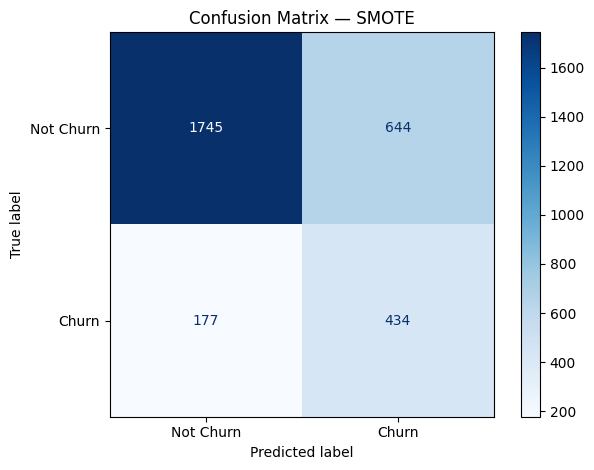

In [12]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Churn", "Churn"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — SMOTE")
plt.grid(False)
plt.tight_layout()
plt.show()

In [13]:
#per class recall
class0_recall = cm[0, 0] / cm[0].sum()
class1_recall = cm[1, 1] / cm[1].sum()

print(f"Class 0 (Not Churn) Recall: {class0_recall:.2f}")
print(f"Class 1 (Churn) Recall: {class1_recall:.2f}")

Class 0 (Not Churn) Recall: 0.73
Class 1 (Churn) Recall: 0.71


## 7. Overall Metrics

In [14]:
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.2f}')
print(f'Precision : {precision_score(y_test, y_pred):.2f}')
print(f'Recall    : {recall_score(y_test, y_pred):.2f}')
print(f'F1 Score  : {f1_score(y_test, y_pred):.2f}')

Accuracy  : 0.73
Precision : 0.40
Recall    : 0.71
F1 Score  : 0.51


In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      2389
           1       0.40      0.71      0.51       611

    accuracy                           0.73      3000
   macro avg       0.66      0.72      0.66      3000
weighted avg       0.80      0.73      0.75      3000



## 8. Predicted Probabilities and Threshold-Independent Metrics

In [16]:
y_prob = pipe.predict_proba(X_test)[:, 1]
y_prob

array([0.13610362, 0.39039384, 0.53037245, ..., 0.72150555, 0.57704352,
       0.15133817], shape=(3000,))

In [17]:
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.2f}")
print(f"PR-AUC Score : {pr_auc:.2f}")

ROC-AUC Score: 0.79
PR-AUC Score : 0.50


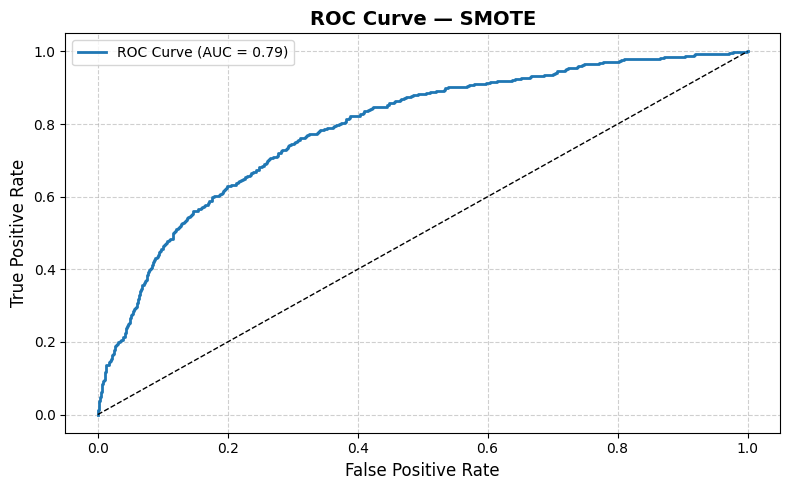

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — SMOTE", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

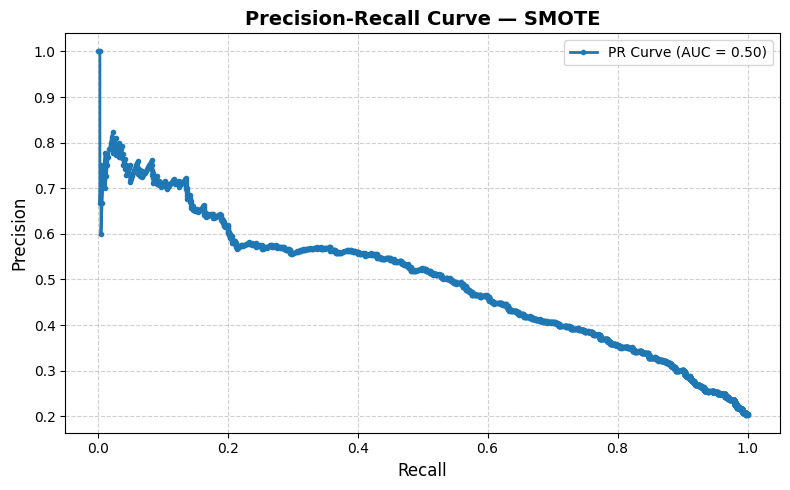

In [19]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, linewidth=2, marker=".", label=f"PR Curve (AUC = {pr_auc:.2f})")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve — SMOTE", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 9. Comparison: Baseline vs. UnderSampling vs. SMOTE *(added)*

Bringing all three approaches together in one table makes the trade-offs immediately
visible, instead of requiring you to flip between three separate notebooks.

In [20]:
comparison = pd.DataFrame({
    "Baseline":      [0.81, 0.62, 0.19, 0.29, 0.79, 0.51],
    "UnderSampling": [0.72, 0.40, 0.73, 0.52, 0.79, 0.50],
    "SMOTE": [
        round(accuracy_score(y_test, y_pred), 2),
        round(precision_score(y_test, y_pred), 2),
        round(recall_score(y_test, y_pred), 2),
        round(f1_score(y_test, y_pred), 2),
        round(roc_auc, 2),
        round(pr_auc, 2),
    ]
}, index=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"])

comparison

,Baseline,UnderSampling,SMOTE
Accuracy,0.81,0.72,0.73
Precision,0.62,0.40,0.40
Recall,0.19,0.73,0.71
F1 Score,0.29,0.52,0.51
ROC-AUC,0.79,0.79,0.79
PR-AUC,0.51,0.50,0.50


## 10. Summary

- **SMOTE and UnderSampling perform very similarly here** on Recall (~0.72-0.73) and
  Precision (~0.40) — both roughly triple the baseline's recall at a similar cost to
  precision and accuracy.
- **Why they land so close together:** ROC-AUC barely moved across all three approaches
  (~0.79). This suggests the *ceiling* on how well these features can separate churners
  from non-churners is fairly fixed — no resampling technique can manufacture
  predictive signal that isn't already present in the underlying features. Resampling
  changes *where the model sets its decision boundary*, not *how much it fundamentally
  knows*.
- **SMOTE's practical advantage over UnderSampling:** it achieves a similar result
  without discarding any real majority-class data — useful when your dataset is small
  and you can't afford to throw rows away. On a larger dataset, this difference would
  matter more than it does here.

The next notebook tries a different strategy entirely — **Class Weighting** — which
doesn't touch the training data at all, and instead tells the model directly to weigh
mistakes on the minority class more heavily during training.